In [3]:
!pip install country_converter

  Using cached country_converter-1.3.2-py3-none-any.whl.metadata (25 kB)
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/10.0 MB 1.2 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/10.0 MB 1.3 MB/s eta 0:00:08
   ---- ----------------------------------- 1.0/10.0 MB 1.3 MB/s eta 0:00:07
   ------ --------------------------------- 1.6/10.0 MB 1.6 MB/s eta 0:00:06
   ------- -------------------------------- 1.8/10.0 MB 1.5 MB/s eta 0:00:06
   --------- ------------------------------ 2.4/10.0 MB 1.6 MB/s eta 0:00:05
   ---------- ----------------------------- 2.6/10.0 MB 1.7 MB/s eta 0:00:05
   ------------ --------------------------- 3.1/10.0 MB 1.7 MB/s eta 0:00:05
   -------------- -------------

In [2]:
%pip install matplotlib seaborn plotly pandas numpy requests

  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached plotly-6.9.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached narwhals-2.25.0-py3-none-any.whl.metadata (15 kB)
Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached plotly-6.9.0-py3-none-any.whl (9.9 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import requests
from country_converter import CountryConverter
import textwrap

import warnings
warnings.filterwarnings("ignore")

In [103]:
from utility import demarcation

In [7]:
#df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets/inflation_cost_of_living_dataset.csv")
df = pd.read_csv("C:/Users/ASUS/Desktop/DATA ANALYSIS/PROJECT FOLDER/world inflation/inflation_cost_of_living_dataset.csv")
df.head()

,country,country_code_x,region,income_level,capital_city,latitude,longitude,country_code_y,inflation_year,inflation_annual_pct,cost_living_index,rent_index,groceries_index,restaurants_index,purchasing_power_index,bread_price_usd,transport_oneway_usd,transport_monthly_pass_usd,rent_monthly_usd,utilities_monthly_usd
0,Aruba,NaN,Latin America & Caribbean,High income,Oranjestad,12.51670,-70.0167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,NaN,"Middle East, North Africa, Afghanistan & Pakistan",Low income,Kabul,34.52280,69.1761,AFG,2024.0,-6.601186,38.2,8.2,36.8,36.9,48.5,0.88,1.05,12.8,85.0,20.0
2,Angola,NaN,Sub-Saharan Africa,Lower middle income,Luanda,-8.81155,13.2420,AGO,2024.0,28.240495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Albania,NaN,Europe & Central Asia,Upper middle income,Tirane,41.33170,19.8172,ALB,2024.0,2.215874,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Andorra,NaN,Europe & Central Asia,High income,Andorra la Vella,42.50750,1.5218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
demarcation()
print("Dataset shape is : ", df.shape)
demarcation()
print(df.isna().sum())
demarcation()
print(df.info())

------------------------------------------------------------
************************************************************
------------------------------------------------------------
Dataset shape is :  (217, 20)
------------------------------------------------------------
************************************************************
------------------------------------------------------------
country                         0
country_code_x                217
region                          0
income_level                    0
capital_city                    6
latitude                        6
longitude                       6
country_code_y                 38
inflation_year                 38
inflation_annual_pct           38
cost_living_index             172
rent_index                    172
groceries_index               172
restaurants_index             172
purchasing_power_index        172
bread_price_usd               181
transport_oneway_usd          189
transport_monthly_pass_usd

In [10]:
demarcation()
print(df.isna().sum())
demarcation()
print(df.isna().sum()/len(df) *100)
demarcation()

------------------------------------------------------------
************************************************************
------------------------------------------------------------
country                         0
country_code_x                217
region                          0
income_level                    0
capital_city                    6
latitude                        6
longitude                       6
country_code_y                 38
inflation_year                 38
inflation_annual_pct           38
cost_living_index             172
rent_index                    172
groceries_index               172
restaurants_index             172
purchasing_power_index        172
bread_price_usd               181
transport_oneway_usd          189
transport_monthly_pass_usd    189
rent_monthly_usd              178
utilities_monthly_usd         192
dtype: int64
------------------------------------------------------------
************************************************************
--

In [11]:
#Drop columns with greater than 50% missing values
null_pct = df.isna().sum()/len(df) *100
# null_pct.index
drop_cols = [col for col in null_pct.index if null_pct[col] > 50]
drop_cols
demarcation()

------------------------------------------------------------
************************************************************
------------------------------------------------------------


In [12]:
df_data = df.drop(columns=drop_cols)
demarcation()
print(df_data.info())
demarcation()

------------------------------------------------------------
************************************************************
------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               217 non-null    str    
 1   region                217 non-null    str    
 2   income_level          217 non-null    str    
 3   capital_city          211 non-null    str    
 4   latitude              211 non-null    float64
 5   longitude             211 non-null    float64
 6   country_code_y        179 non-null    str    
 7   inflation_year        179 non-null    float64
 8   inflation_annual_pct  179 non-null    float64
dtypes: float64(4), str(5)
memory usage: 15.4 KB
None
------------------------------------------------------------
************************************************

In [13]:
cc = CountryConverter()
df_data['IS03_country'] = cc.convert(df_data['country'], to="iso3")
df_data.head()

Channel Islands not found in regex
Naoero not found in regex


,country,region,income_level,capital_city,latitude,longitude,country_code_y,inflation_year,inflation_annual_pct,IS03_country
0,Aruba,Latin America & Caribbean,High income,Oranjestad,12.51670,-70.0167,NaN,NaN,NaN,ABW
1,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,Kabul,34.52280,69.1761,AFG,2024.0,-6.601186,AFG
2,Angola,Sub-Saharan Africa,Lower middle income,Luanda,-8.81155,13.2420,AGO,2024.0,28.240495,AGO
3,Albania,Europe & Central Asia,Upper middle income,Tirane,41.33170,19.8172,ALB,2024.0,2.215874,ALB
4,Andorra,Europe & Central Asia,High income,Andorra la Vella,42.50750,1.5218,NaN,NaN,NaN,AND


In [14]:
df_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               217 non-null    str    
 1   region                217 non-null    str    
 2   income_level          217 non-null    str    
 3   capital_city          211 non-null    str    
 4   latitude              211 non-null    float64
 5   longitude             211 non-null    float64
 6   country_code_y        179 non-null    str    
 7   inflation_year        179 non-null    float64
 8   inflation_annual_pct  179 non-null    float64
 9   IS03_country          217 non-null    str    
dtypes: float64(4), str(6)
memory usage: 17.1 KB


In [64]:
#Clean inflation year column
years = df_data['inflation_year'].astype(str)
corr_year = [year.split(".")[0] if type(year) != float else year for year in years]
df_data['inflation_year'] = corr_year
df_data['inflation_year'] = df_data['inflation_year']
df_data.head()

,country,region,income_level,capital_city,latitude,longitude,country_code_y,inflation_year,inflation_annual_pct,IS03_country
0,Aruba,Latin America & Caribbean,High income,Oranjestad,12.51670,-70.0167,NaN,NaN,NaN,ABW
1,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,Kabul,34.52280,69.1761,AFG,2024,-6.601186,AFG
2,Angola,Sub-Saharan Africa,Lower middle income,Luanda,-8.81155,13.2420,AGO,2024,28.240495,AGO
3,Albania,Europe & Central Asia,Upper middle income,Tirane,41.33170,19.8172,ALB,2024,2.215874,ALB
4,Andorra,Europe & Central Asia,High income,Andorra la Vella,42.50750,1.5218,NaN,NaN,NaN,AND


In [66]:
demarcation()
print("")
print("Unique regions in dataset")
print("")
print(df_data['region'].unique())
demarcation()
df_data['region'].value_counts()

------------------------------------------------------------
************************************************************
------------------------------------------------------------

Unique regions in dataset

<StringArray>
[                       'Latin America & Caribbean ',
 'Middle East, North Africa, Afghanistan & Pakistan',
                               'Sub-Saharan Africa ',
                             'Europe & Central Asia',
                               'East Asia & Pacific',
                                        'South Asia',
                                     'North America']
Length: 7, dtype: str
------------------------------------------------------------
************************************************************
------------------------------------------------------------


region
Europe & Central Asia                                58
Sub-Saharan Africa                                   48
Latin America & Caribbean                            42
East Asia & Pacific                                  37
Middle East, North Africa, Afghanistan & Pakistan    23
South Asia                                            6
North America                                         3
Name: count, dtype: int64

#EXPLORATORY DATA ANALYSIS

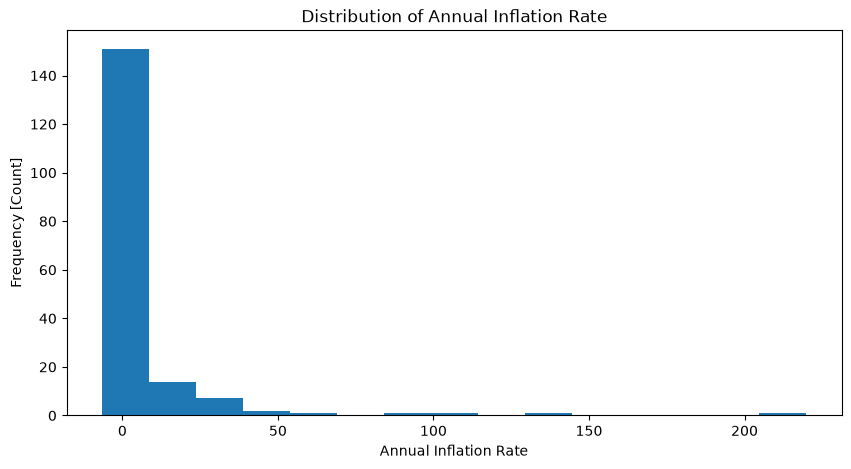

In [67]:
fig, ax = plt.subplots(figsize=(10,5))
plt.hist(x = df_data['inflation_annual_pct'], bins=15)
plt.xlabel("Annual Inflation Rate")
plt.ylabel("Frequency [Count]")
plt.title("Distribution of Annual Inflation Rate")
plt.show()

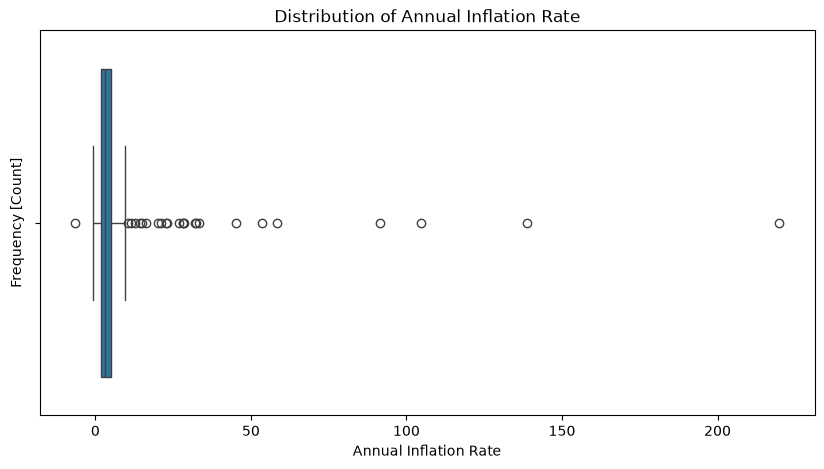

In [68]:
fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(x=df_data['inflation_annual_pct'], ax=ax)
plt.xlabel("Annual Inflation Rate")
plt.ylabel("Frequency [Count]")
plt.title("Distribution of Annual Inflation Rate")
plt.show()

------------------------------------------------------------
************************************************************
------------------------------------------------------------
Inflation Year Distribtion

inflation_year
2024    174
2022      3
2023      2
Name: count, dtype: int64
------------------------------------------------------------
************************************************************
------------------------------------------------------------


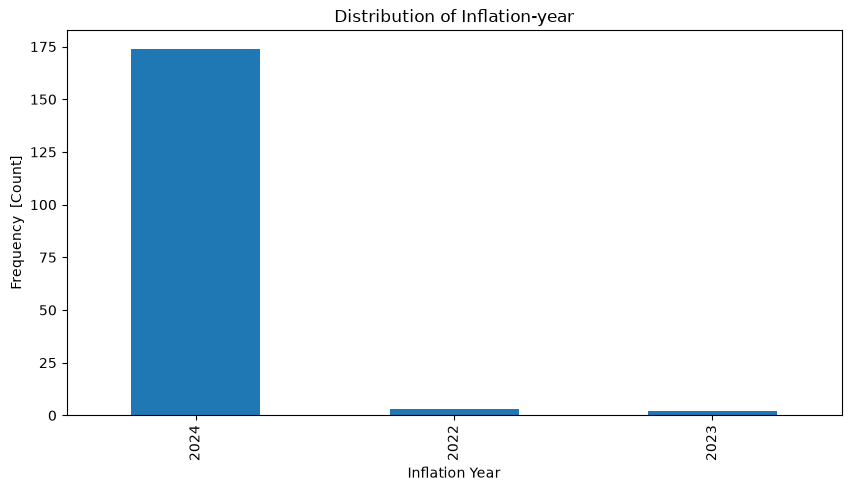

In [69]:
demarcation()
print("Inflation Year Distribtion")
print("")
print(df_data['inflation_year'].value_counts())
demarcation()

fig, ax = plt.subplots(figsize=(10,5))
df_data['inflation_year'].value_counts().plot(kind = "bar", ax=ax)
plt.xlabel("Inflation Year")
plt.ylabel("Frequency  [Count]")
plt.title("Distribution of Inflation-year")
plt.show()

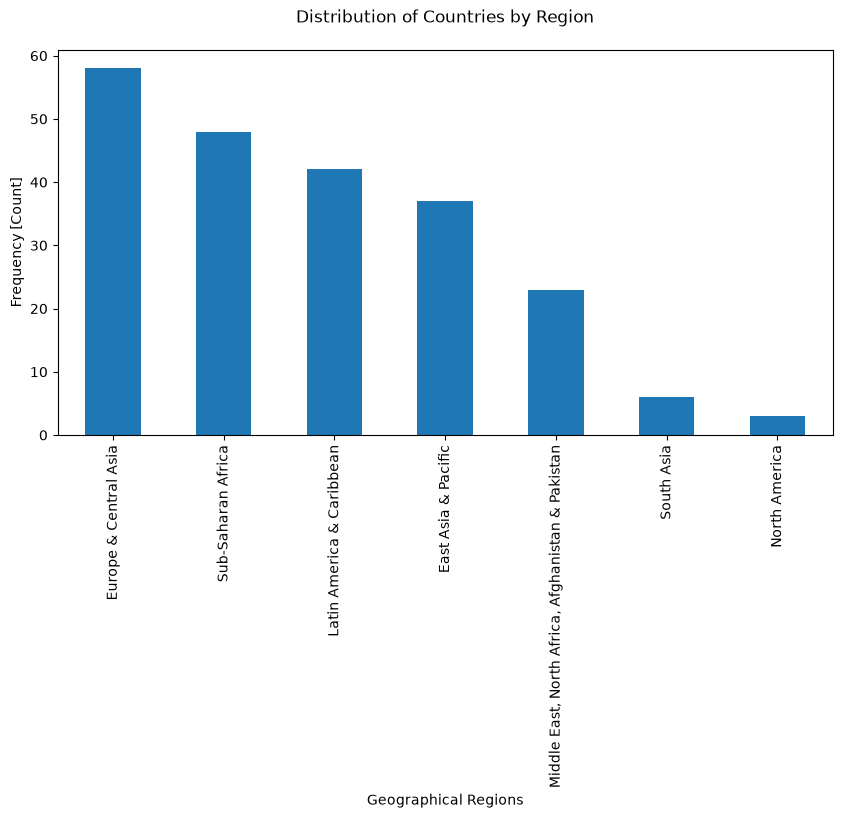

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
#sns.countplot(data=df_data, x="region", axes=ax)
df_data['region'].value_counts().plot(kind="bar", ax=ax)
plt.xticks(rotation = 90)
plt.xlabel("Geographical Regions")
plt.ylabel("Frequency [Count]")
plt.title("Distribution of Countries by Region", y=1.05)
plt.show()

In [70]:
income_inflation = df_data.groupby("income_level")["inflation_annual_pct"].mean().sort_values()
income_inflation

income_level
High income             2.423697
Upper middle income     8.780368
Lower middle income    12.354631
Low income             20.678132
Name: inflation_annual_pct, dtype: float64

In [71]:
fig = px.bar(
    data_frame = income_inflation,
    x = income_inflation.index,
    y = income_inflation.values,
    color = income_inflation.values,
    color_continuous_scale= px.colors.sequential.Blues,
    title = "Annual-Inflation Rate Categorized by Income Level of Contries")
fig.update_layout(
    xaxis_title = "Income Level",
    yaxis_title = "Annual Inflation Rate"
)
fig.show()

In [72]:
df_data.groupby(["income_level", "region"])["country"].size()


income_level         region                                           
High income          East Asia & Pacific                                  15
                     Europe & Central Asia                                40
                     Latin America & Caribbean                            19
                     Middle East, North Africa, Afghanistan & Pakistan     8
                     North America                                         3
                     Sub-Saharan Africa                                    1
Low income           East Asia & Pacific                                   1
                     Middle East, North Africa, Afghanistan & Pakistan     3
                     Sub-Saharan Africa                                   21
Lower middle income  East Asia & Pacific                                   8
                     Europe & Central Asia                                 3
                     Latin America & Caribbean                             5
     

In [100]:
mask = df_data['income_level'] == "Low income"
mask_b = df_data['income_level'] == "Lower middle income"
mask_c = df_data['income_level'] == "Upper middle income"
mask_d = df_data['income_level'] == "High income"

low_income = df_data[mask]
lower_middle_income = df_data[mask_b]
upper_middle_income = df_data[mask_c]
high_income = df_data[mask_d]

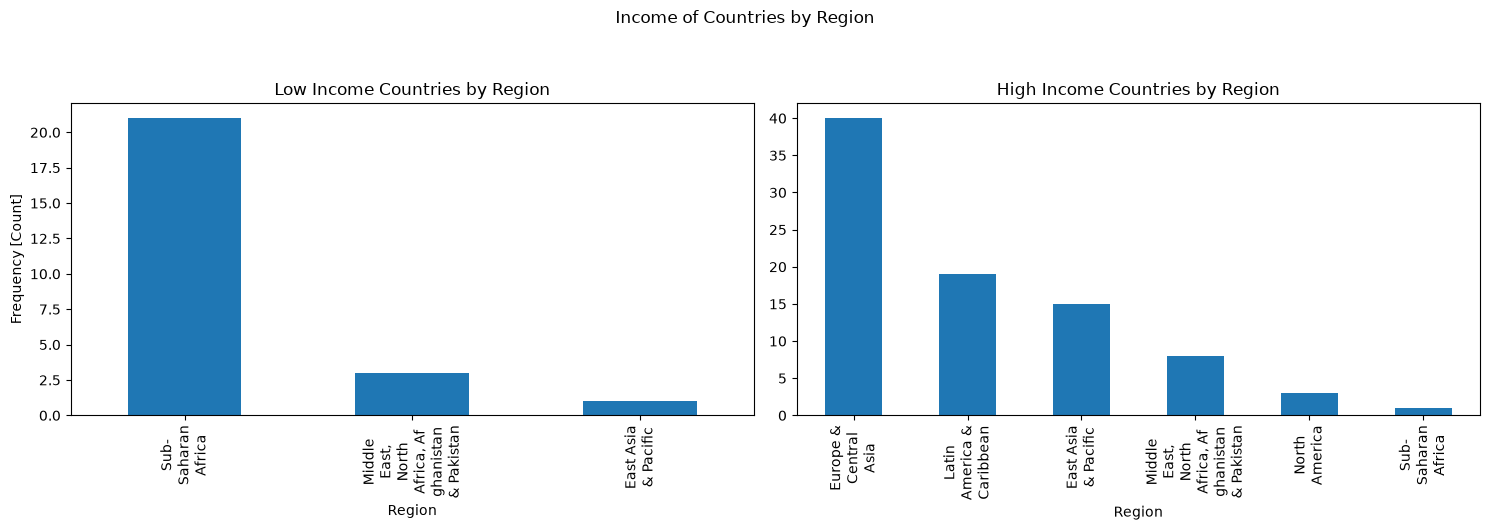

In [74]:
#Plot of ditribution of countries by income levels
fig, ax = plt.subplots(1,2, figsize=(15,5))

#lower_middle_income['region'].value_counts().plot(kind="bar", ax=ax[1,0])
#upper_middle_income['region'].value_counts().plot(kind="bar", ax=ax[1,1])

low_income['region'].value_counts().plot(kind="bar", ax=ax[0])
labels = [
    textwrap.fill(label.get_text(), width=10)
    for label in ax[0].get_xticklabels() ]
ax[0].set_xticklabels(labels)
ax[0].set_ylabel("Frequency [Count]")
ax[0].set_xlabel("Region")
ax[0].set_title("Low Income Countries by Region")


high_income['region'].value_counts().plot(kind="bar", ax=ax[1])
labels = [
    textwrap.fill(label.get_text(), width=10)
    for label in ax[1].get_xticklabels() ]
ax[1].set_xticklabels(labels)
ax[1].set_xlabel("Region")
ax[1].set_title("High Income Countries by Region")

#plt.xticks(rotation = 90)
#plt.xlabel("Geographical Regions")


plt.suptitle("Income of Countries by Region", y=1.05)
plt.tight_layout()
plt.show()

In [75]:
#Chexk Sub-Saharan High Income Country
high_income["region"] = (
    high_income["region"]
    .astype(str)
    .str.strip()
)

df_data["region"] = df_data["region"].str.strip()

maska = high_income['region'] ==  "Sub-Saharan Africa"
high_income[maska]

,country,region,income_level,capital_city,latitude,longitude,country_code_y,inflation_year,inflation_annual_pct,IS03_country
185,Seychelles,Sub-Saharan Africa,High income,Victoria,-4.6309,55.4466,SYC,2024,0.311726,SYC


In [76]:
#categorize inflation by region
region_inflation = df_data.groupby("region")["inflation_annual_pct"].mean().sort_values()
region_inflation

region
North America                                         2.665555
East Asia & Pacific                                   3.134317
South Asia                                            3.974462
Europe & Central Asia                                 4.425715
Middle East, North Africa, Afghanistan & Pakistan     9.527164
Latin America & Caribbean                            11.208234
Sub-Saharan Africa                                   15.535423
Name: inflation_annual_pct, dtype: float64

In [77]:
fig = px.bar(
    data_frame = region_inflation,
    x = region_inflation.index,
    y = region_inflation.values,
    color = region_inflation.values,
    color_continuous_scale= px.colors.sequential.Reds,
    title = "Annual Inflation Rate by Region"
)
fig.update_layout(
    xaxis_title = "Region",
    yaxis_title = "Annual Inflation Rate"
)
fig.show()

In [79]:
fig = px.choropleth(
    data_frame = df_data,
    locations = "IS03_country",
    #projection = "orthographic",
    projection = "robinson",
    #projection = "equirectangular",
    color = "inflation_annual_pct",
    color_continuous_scale= px.colors.sequential.Reds,
    title = "Inflation By Country"
)

fig.show()

In [80]:
#filter out top 30 countries with inflation
top_30 = df_data.sort_values(by=["inflation_annual_pct"], ascending=False).head(30).reset_index().drop(columns="index")

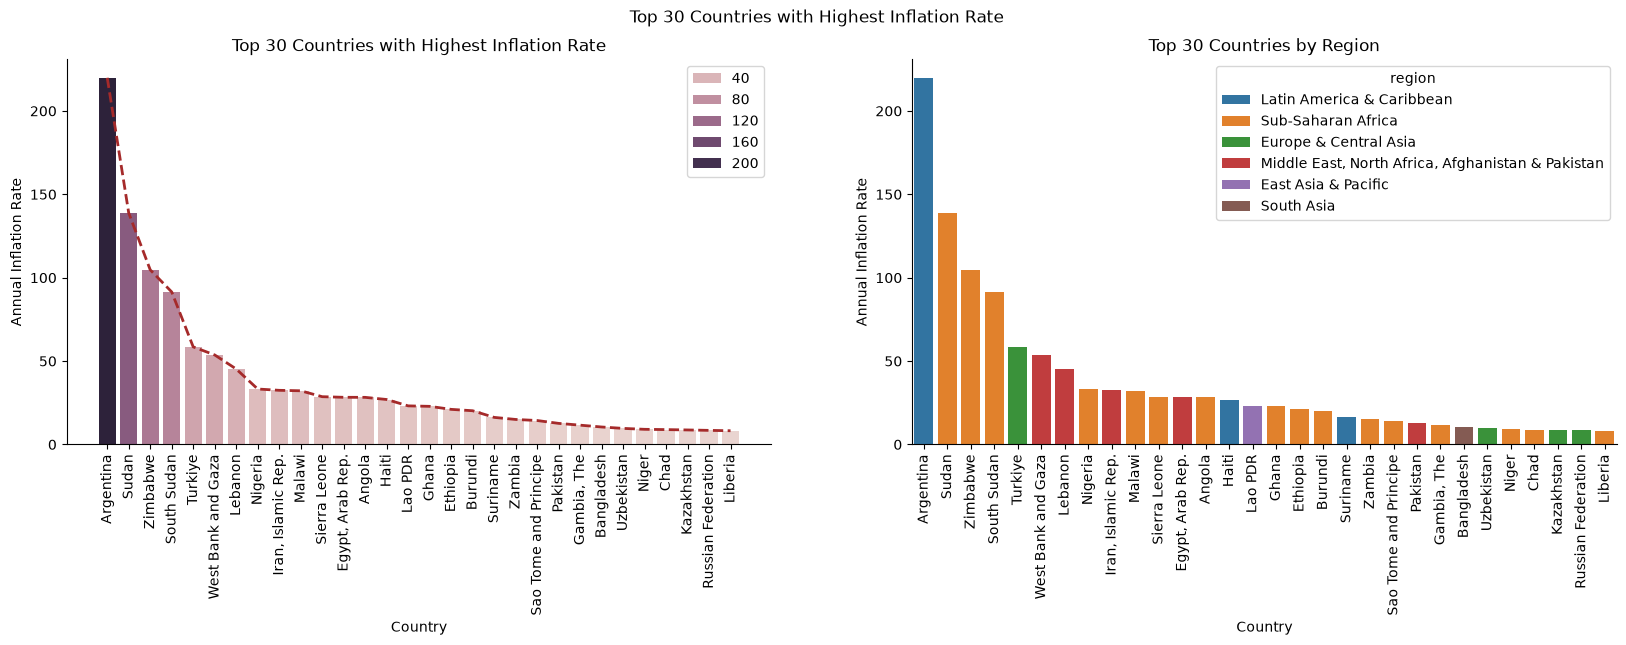

In [81]:
fig,(ax,ax2) = plt.subplots(1, 2, figsize=(20,5))
sns.barplot(data=top_30, x="country", y="inflation_annual_pct", ax=ax, hue="inflation_annual_pct")
sns.lineplot(data=top_30, x="country", y="inflation_annual_pct", ax=ax, color="brown", linestyle="--", linewidth="2")
ax.set_xlabel("Country")
ax.set_ylabel("Annual Inflation Rate")
ax.tick_params(axis="x", rotation=90)
ax.set_title("Top 30 Countries with Highest Inflation Rate")

sns.barplot(data=top_30, x="country", y="inflation_annual_pct", ax=ax2, hue="region")
ax2.set_xlabel("Country")
ax2.set_ylabel("Annual Inflation Rate")
ax2.set_title("Top 30 Countries by Region")
ax2.tick_params(axis="x", rotation=90)

sns.despine()
plt.suptitle("Top 30 Countries with Highest Inflation Rate")
plt.show()

In [82]:
fig = px.bar(
    data_frame = top_30.head(10),
    x = "country",
    y = "inflation_annual_pct",
    color = "inflation_annual_pct",
    color_continuous_scale= px.colors.sequential.Reds,
    title = "Top 10 Countries with Highest Inflation Rate"
)
fig.update_layout(
    xaxis_title = "Country",
    yaxis_title = "Annual Inflation Rate"
)
fig.show()

#CONCLUSION